# 🧠 YOLO Document Layout Detection + SALG on DocLayNet
**Pipeline:** YOLOv26 (pretrained) → Fine-tune on DocLayNet → Semantic-Aware Layout Grouping (SALG)

**Disk Strategy:** Stream dataset in shards to Google Drive instead of downloading all 27.4 GB to Colab's 50 GB disk.

## Cell 1 — Mount Google Drive & Setup Directories

In [ ]:
# Mount Google Drive — dataset + checkpoints persist here (avoids the 27.4 GB disk issue)
from google.colab import drive
drive.mount('/content/drive')

import os

BASE      = '/content/drive/MyDrive/doclayout_yolo'
DATA_DIR  = f'{BASE}/dataset'
MODEL_DIR = f'{BASE}/models'
OUT_DIR   = f'{BASE}/runs'

for d in [DATA_DIR, MODEL_DIR, OUT_DIR,
          f'{DATA_DIR}/images/train', f'{DATA_DIR}/images/val',
          f'{DATA_DIR}/labels/train', f'{DATA_DIR}/labels/val']:
    os.makedirs(d, exist_ok=True)

print("✅ Drive mounted, directories ready.")
print(f"   Base path: {BASE}")

Mounted at /content/drive
✅ Drive mounted, directories ready.
   Base path: /content/drive/MyDrive/doclayout_yolo


## Cell 2 — Install Dependencies

In [ ]:
!pip install -q ultralytics huggingface_hub datasets Pillow tqdm

import torch
print(f"✅ PyTorch {torch.__version__} | GPU: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'None (use Runtime > Change runtime type > GPU)'}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 77.6 MB/s eta 0:00:00
✅ PyTorch 2.10.0+cu128 | GPU: Tesla T4


## Cell 3 — Download Pretrained YOLOv26 Model from HuggingFace

In [ ]:
from huggingface_hub import hf_hub_download
from pathlib import Path

# Choose model size: 'n' = nano (fastest, recommended), 's' = small, 'm' = medium
MODEL_SIZE = 'n'  # Change to 's' or 'm' for higher accuracy

model_filename = f'yolo26{MODEL_SIZE}_doc_layout.pt'
model_path = Path(MODEL_DIR) / model_filename

if not model_path.exists():
    print(f"Downloading {model_filename} to Drive...")
    hf_hub_download(
        repo_id='Armaggheddon/yolo26-document-layout',
        filename=model_filename,
        repo_type='model',
        local_dir=MODEL_DIR
    )
    print("✅ Model downloaded to Drive (won't re-download next session).")
else:
    print(f"✅ Model already exists at {model_path}, skipping download.")

print(f"   Model path: {model_path}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


yolo26n_doc_layout.pt:   0%|          | 0.00/5.55M [00:00<?, ?B/s]

✅ Model downloaded to Drive (won't re-download next session).
   Model path: /content/drive/MyDrive/doclayout_yolo/models/yolo26n_doc_layout.pt


## Cell 4 — Stream DocLayNet Dataset to Drive (Solves the 27.4 GB Disk Issue)

> **Key idea:** We use HuggingFace `datasets` streaming mode to iterate over the dataset shard-by-shard and write converted YOLO-format files directly to Google Drive, without ever storing the full 27.4 GB on Colab's ephemeral disk.
>
> ⏱ This cell takes ~30–60 min on first run. Re-runs are instant (files already exist on Drive).

In [ ]:
import json
from pathlib import Path
from PIL import Image
from tqdm.auto import tqdm
from datasets import load_dataset
import io

# DocLayNet v1.2 class mapping — ordered by category_id integer (0-based)
# category_id in dataset IS the index into this list
CLASSES = [
    'Caption',        # 0
    'Footnote',       # 1
    'Formula',        # 2
    'List-item',      # 3
    'Page-footer',    # 4
    'Page-header',    # 5
    'Picture',        # 6
    'Section-header', # 7
    'Table',          # 8
    'Text',           # 9
    'Title'           # 10
]
CLASS_TO_ID = {c: i for i, c in enumerate(CLASSES)}

def convert_bbox_to_yolo(bbox, img_w, img_h):
    """Convert COCO [x, y, w, h] (pixels) to YOLO [cx, cy, w, h] (normalised 0-1)."""
    x, y, w, h = bbox
    cx = (x + w / 2) / img_w
    cy = (y + h / 2) / img_h
    bw = w / img_w
    bh = h / img_h
    # Clamp to [0,1] to avoid invalid labels
    return max(0,min(1,cx)), max(0,min(1,cy)), max(0,min(1,bw)), max(0,min(1,bh))

def process_split(hf_split, folder_name, max_samples=None):
    """hf_split: HuggingFace split key ('train'/'validation'/'test')
       folder_name: local folder name ('train'/'val')"""
    img_dir = Path(DATA_DIR) / 'images' / folder_name
    lbl_dir = Path(DATA_DIR) / 'labels' / folder_name
    img_dir.mkdir(parents=True, exist_ok=True)
    lbl_dir.mkdir(parents=True, exist_ok=True)

    # Count already processed files to allow resuming
    already_done = len(list(img_dir.glob('*.jpg')))
    if already_done > 0:
        print(f"  [{folder_name}] {already_done} files already on Drive — resuming from where we left off.")

    # Stream dataset: never loads full 27.4 GB to disk
    ds = load_dataset(
        'docling-project/DocLayNet-v1.2',
        split=hf_split,
        streaming=True,
        trust_remote_code=True
    )

    saved = 0
    skipped = 0
    for idx, sample in enumerate(tqdm(ds, desc=f'{folder_name}')):
        if max_samples and idx >= max_samples:
            break

        stem = f'{folder_name}_{idx:06d}'
        img_path = img_dir / f'{stem}.jpg'
        lbl_path = lbl_dir / f'{stem}.txt'

        # Skip if already saved (supports resume)
        if img_path.exists() and lbl_path.exists():
            skipped += 1
            continue

        # Save image
        img = sample['image']  # PIL Image
        img_w, img_h = img.size
        img.convert('RGB').save(img_path, 'JPEG', quality=90)

        # Build YOLO label lines
        # DocLayNet v1.2 actual fields:
        #   sample['bboxes']       = List[ [x, y, w, h] ]  — COCO format, pixels
        #   sample['category_id']  = List[int]             — 0-based class id (parallel list)
        lines = []
        bboxes       = sample.get('bboxes', [])
        category_ids = sample.get('category_id', [])
        for bbox, cls_id in zip(bboxes, category_ids):
            if cls_id < 0 or cls_id >= len(CLASSES):
                continue
            cx, cy, bw, bh = convert_bbox_to_yolo(bbox, img_w, img_h)
            if bw > 0 and bh > 0:
                lines.append(f'{cls_id} {cx:.6f} {cy:.6f} {bw:.6f} {bh:.6f}')

        lbl_path.write_text('\n'.join(lines))
        saved += 1

    print(f'  [{folder_name}] Done — {saved} new, {skipped} skipped (resume-safe). Total: {saved+skipped}')

# ─────────────────────────────────────────────────────────────
# TRAINING SET
# Set max_samples=None to use all data.
# For a fast experiment, start with 5000 train + 1000 val.
# ─────────────────────────────────────────────────────────────
FAST_EXPERIMENT = True   # ← Set False to use the full dataset

train_limit = 5000 if FAST_EXPERIMENT else None
val_limit   = 1000 if FAST_EXPERIMENT else None

print(f"Mode: {'FAST (subset)' if FAST_EXPERIMENT else 'FULL dataset'}")
print("Processing train split...")
process_split('train', 'train', max_samples=train_limit)
print("Processing validation split...")
process_split('validation', 'val', max_samples=val_limit)  # HF split='validation', folder='val'
print("\n✅ Dataset ready on Google Drive.")

`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'docling-project/DocLayNet-v1.2' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.
ERROR:datasets.load:`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'docling-project/DocLayNet-v1.2' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.


Mode: FAST (subset)
Processing train split...


README.md: 0.00B [00:00, ?B/s]

Resolving data files:   0%|          | 0/72 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/72 [00:00<?, ?it/s]

...

  [train] Done — 5000 new, 0 skipped (resume-safe). Total: 5000
Processing validation split...


Resolving data files:   0%|          | 0/72 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/72 [00:00<?, ?it/s]

val: 0it [00:00, ?it/s]

  [val] Done — 1000 new, 0 skipped (resume-safe). Total: 1000

✅ Dataset ready on Google Drive.


## Cell 5 — Write YAML Config for YOLO Training

In [ ]:
import yaml

yaml_cfg = {
    'path'  : DATA_DIR,
    'train' : 'images/train',
    'val'   : 'images/val',
    'nc'    : 11,
    'names' : CLASSES
}

yaml_path = f'{BASE}/doclaynet.yaml'
with open(yaml_path, 'w') as f:
    yaml.dump(yaml_cfg, f, default_flow_style=False)

print(f'✅ YAML config saved: {yaml_path}')
print(yaml.dump(yaml_cfg))

✅ YAML config saved: /content/drive/MyDrive/doclayout_yolo/doclaynet.yaml
names:
- Caption
- Footnote
- Formula
- List-item
- Page-footer
- Page-header
- Picture
- Section-header
- Table
- Text
- Title
nc: 11
path: /content/drive/MyDrive/doclayout_yolo/dataset
train: images/train
val: images/val



## Cell 6 — Fine-tune YOLOv26 on DocLayNet

> **Accuracy & speed optimizations applied:**
> - `imgsz=1280` — paper shows major accuracy drop at 640; this matches original training
> - `pretrained=True` — starts from HuggingFace weights, not scratch
> - `cache='ram'` — caches images in RAM for faster dataloading
> - `cos_lr=True` + `warmup_epochs=3` — stable convergence
> - `augment=True`, `mosaic=1.0`, `copy_paste=0.3` — document-appropriate augmentations
> - `amp=True` — mixed precision (2× speed on T4/A100)
> - `project` pointing to Drive — checkpoints survive runtime crashes

In [6]:
from ultralytics import YOLO

model = YOLO(str(model_path))  # Load pretrained weights from Drive

results = model.train(
    data       = yaml_path,
    epochs     = 3,           # ⚡ Quick test: was 30          # Increase to 50–100 for full dataset
    imgsz      = 640,          # ⚡ Quick test: was 1280         # Critical for small elements (footnotes, captions)
    batch      = 8,            # ⚡ Quick test: was 4            # T4 VRAM-safe; increase to 8 if using A100
    device     = 0,

    # Speed
    amp        = True,         # Mixed precision — ~2x faster
    cache      = 'disk',       # ⚡ Quick test: safer than ram        # Cache dataset images in RAM
    workers    = 2,            # ⚡ Quick test: was 4

    # Learning schedule
    lr0        = 0.001,
    lrf        = 0.01,
    warmup_epochs = 1,         # ⚡ Quick test: was 3
    cos_lr     = True,

    # Accuracy
    optimizer  = 'AdamW',
    weight_decay = 0.0005,
    label_smoothing = 0.05,

    # Augmentation (document-friendly)
    mosaic     = 0.0,          # ⚡ Quick test: disabled
    copy_paste = 0.0,          # ⚡ Quick test: disabled
    degrees    = 0.0,   # No rotation — documents are always upright
    fliplr     = 0.0,   # No horizontal flip — text direction matters
    flipud     = 0.0,
    hsv_h      = 0.015,
    hsv_s      = 0.3,
    hsv_v      = 0.3,

    # Persistence
    project    = OUT_DIR,
    name       = f'yolo26{MODEL_SIZE}_doclaynet',
    save_period = 1,           # ⚡ Quick test: was 5    # Save checkpoint every 5 epochs
    patience   = 3,            # ⚡ Quick test: was 15    # Early stopping
)

print('\n✅ Training complete!')
print(f'   Best model: {OUT_DIR}/yolo26{MODEL_SIZE}_doclaynet/weights/best.pt')

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
WARNING ⚠️ 'label_smoothing' is deprecated and will be removed in the future.
Ultralytics 8.4.33 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=disk, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/content/drive/MyDrive/doclayout_yolo/doclaynet.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=3, erasing=0.4, exist_ok=False, fliplr=0.0, flipud=0.0, format=torchs

## Cell 7 — Evaluate on Validation Set

In [7]:
from ultralytics import YOLO

best_model_path = f'{OUT_DIR}/yolo26{MODEL_SIZE}_doclaynet/weights/best.pt'
model_eval = YOLO(best_model_path)

metrics = model_eval.val(
    data    = yaml_path,
    imgsz   = 640,   # ⚡ Quick test: was 1280
    batch   = 8,     # ⚡ Quick test: was 4
    device  = 0,
    split   = 'val',
    project = OUT_DIR,
    name    = 'eval',
)

print('\n📊 Validation Results:')
print(f'  mAP@50    : {metrics.box.map50:.4f}')
print(f'  mAP@50-95 : {metrics.box.map:.4f}')
print(f'  Precision : {metrics.box.mp:.4f}')
print(f'  Recall    : {metrics.box.mr:.4f}')

print('\nPer-class mAP@50:')
for cls_name, ap in zip(CLASSES, metrics.box.ap50):
    bar = '█' * int(ap * 30)
    print(f'  {cls_name:<16} {bar:<30} {ap:.3f}')

Ultralytics 8.4.33 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO26n summary (fused): 122 layers, 2,376,981 parameters, 0 gradients, 5.2 GFLOPs
val: Fast image access ✅ (ping: 0.4±0.1 ms, read: 25.4±11.6 MB/s, size: 159.3 KB)
val: Scanning /content/drive/MyDrive/doclayout_yolo/dataset/labels/val.cache... 1000 images, 6 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1000/1000 190.7Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 125/125 3.3it/s 38.1s
                   all       1000      13501      0.768      0.626      0.663      0.492
              Footnote        102        261      0.604      0.475      0.529      0.408
               Formula          7         17          1          0   0.000845   0.000676
           Page-footer        194       1166      0.718      0.815      0.849      0.689
           Page-header        749        876      0.686      0.783      0.707      0.248
              

## Cell 8 — Semantic-Aware Layout Grouping (SALG)

> SALG groups raw YOLO detections into semantic document blocks by:
> 1. **Vertical proximity clustering** — nearby text/header elements are grouped into sections
> 2. **Caption anchoring** — captions are associated with their nearest Figure/Table
> 3. **Header hierarchy detection** — Title → Section-header → Text flow is inferred
> 4. **Reading-order sorting** — groups are sorted top-left → bottom-right (column-aware)

In [ ]:
import numpy as np
from dataclasses import dataclass, field
from typing import List, Tuple, Dict, Optional


@dataclass
class Detection:
    cls_name : str
    cls_id   : int
    conf     : float
    box      : Tuple[float,float,float,float]  # x1,y1,x2,y2 in pixels

    @property
    def cx(self): return (self.box[0] + self.box[2]) / 2
    @property
    def cy(self): return (self.box[1] + self.box[3]) / 2
    @property
    def w(self):  return self.box[2] - self.box[0]
    @property
    def h(self):  return self.box[3] - self.box[1]


@dataclass
class SemanticGroup:
    group_type   : str                    # 'section', 'float', 'header', 'footer', 'isolated'
    elements     : List[Detection]
    anchor       : Optional[Detection] = None  # For captions: the parent figure/table
    reading_order: int = 0

    @property
    def bbox(self):
        x1 = min(d.box[0] for d in self.elements)
        y1 = min(d.box[1] for d in self.elements)
        x2 = max(d.box[2] for d in self.elements)
        y2 = max(d.box[3] for d in self.elements)
        return x1, y1, x2, y2


class SALG:
    """
    Semantic-Aware Layout Grouping.
    Converts raw YOLO detections into structured semantic groups.
    """

    FLOAT_CLASSES  = {'Table', 'Picture', 'Formula'}
    FLOW_CLASSES   = {'Text', 'List-item', 'Section-header', 'Title'}
    ANCHOR_CLASSES = {'Caption'}
    MARGIN_CLASSES = {'Page-header', 'Page-footer', 'Footnote'}

    def __init__(
        self,
        img_h            : int,
        img_w            : int,
        col_gap_ratio    : float = 0.08,   # Horizontal gap fraction to detect columns
        vert_gap_ratio   : float = 0.04,   # Vertical gap fraction to split sections
        caption_radius   : float = 0.15,   # Max distance (fraction of img_h) to anchor caption
    ):
        self.img_h           = img_h
        self.img_w           = img_w
        self.col_gap         = col_gap_ratio  * img_w
        self.vert_gap        = vert_gap_ratio * img_h
        self.caption_radius  = caption_radius * img_h

    # ──────────────────────────────────────────────────────────
    # 1. Detect column layout
    # ──────────────────────────────────────────────────────────
    def _detect_columns(self, dets: List[Detection]) -> int:
        """Returns 1 or 2 columns based on horizontal center distribution."""
        if not dets:
            return 1
        centers = np.array([d.cx for d in dets])
        mid = self.img_w / 2
        left  = np.sum(centers < mid - self.col_gap)
        right = np.sum(centers > mid + self.col_gap)
        return 2 if (left > 2 and right > 2) else 1

    # ──────────────────────────────────────────────────────────
    # 2. Assign column index
    # ──────────────────────────────────────────────────────────
    def _column_of(self, det: Detection, n_cols: int) -> int:
        if n_cols == 1:
            return 0
        return 0 if det.cx < self.img_w / 2 else 1

    # ──────────────────────────────────────────────────────────
    # 3. Cluster flow elements into vertical sections (per column)
    # ──────────────────────────────────────────────────────────
    def _cluster_flow(self, dets: List[Detection]) -> List[List[Detection]]:
        """Groups consecutive (by y) detections that are close together."""
        if not dets:
            return []
        sorted_dets = sorted(dets, key=lambda d: d.box[1])  # sort by y1
        groups = [[sorted_dets[0]]]
        for det in sorted_dets[1:]:
            prev_y2 = groups[-1][-1].box[3]
            if det.box[1] - prev_y2 < self.vert_gap:
                groups[-1].append(det)
            else:
                groups.append([det])
        return groups

    # 4. Anchor captions to nearest float
    def _anchor_captions(
        self,
        captions : List[Detection],
        floats   : List[Detection]
    ) -> Dict[int, Detection]:
        """Returns {caption_idx: float_detection} mapping."""
        anchors = {}
        for i, cap in enumerate(captions):
            best_dist = float('inf')
            best_f    = None
            for f in floats:
                dist = abs(cap.cy - f.cy)
                if dist < best_dist and dist < self.caption_radius:
                    best_dist = dist
                    best_f    = f
            if best_f:
                anchors[i] = best_f
        return anchors

    # 5. Main grouping method
    def group(self, detections: List[Detection]) -> List[SemanticGroup]:
        """
        Returns a reading-order list of SemanticGroup objects.
        """
        groups: List[SemanticGroup] = []

        # Partition by semantic role
        flow_dets    = [d for d in detections if d.cls_name in self.FLOW_CLASSES]
        float_dets   = [d for d in detections if d.cls_name in self.FLOAT_CLASSES]
        caption_dets = [d for d in detections if d.cls_name in self.ANCHOR_CLASSES]
        margin_dets  = [d for d in detections if d.cls_name in self.MARGIN_CLASSES]

        # Detect columns using flow elements
        n_cols = self._detect_columns(flow_dets)

        # Group flow elements per column
        for col in range(n_cols):
            col_dets = [d for d in flow_dets if self._column_of(d, n_cols) == col]
            for cluster in self._cluster_flow(col_dets):
                # Determine group type by dominant class
                types = [d.cls_name for d in cluster]
                if 'Title' in types:
                    gtype = 'header'
                elif 'Section-header' in types:
                    gtype = 'section'
                else:
                    gtype = 'flow'
                groups.append(SemanticGroup(group_type=gtype, elements=cluster))

        # Anchor captions to floats
        cap_anchors = self._anchor_captions(caption_dets, float_dets)
        anchored_caps = set(cap_anchors.keys())

        # Create float groups (Table/Picture/Formula + their captions)
        for f in float_dets:
            float_elems = [f]
            for ci, anchor in cap_anchors.items():
                if anchor is f:
                    float_elems.append(caption_dets[ci])
            groups.append(SemanticGroup(
                group_type='float',
                elements=float_elems,
                anchor=f
            ))

        # Unanchored captions as isolated groups
        for i, cap in enumerate(caption_dets):
            if i not in anchored_caps:
                groups.append(SemanticGroup(group_type='isolated', elements=[cap]))

        # Margin elements (headers/footers/footnotes)
        for det in margin_dets:
            groups.append(SemanticGroup(group_type='margin', elements=[det]))

        # ── Reading order: column-aware, top-to-bottom ──
        def reading_key(g: SemanticGroup):
            x1, y1, x2, y2 = g.bbox
            col = 0 if x1 < self.img_w / 2 else 1
            # Margin elements float to top/bottom
            if g.group_type == 'margin':
                margin_penalty = 0 if y1 < self.img_h * 0.1 else 1e6
                return (margin_penalty, y1)
            return (col * 1e4, y1)

        groups.sort(key=reading_key)
        for i, g in enumerate(groups):
            g.reading_order = i

        return groups


print('✅ SALG class defined.')

✅ SALG class defined.


## Cell 9 — Run Inference + SALG on a Test Image

In [9]:
import glob
import random
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image as PILImage
from ultralytics import YOLO

# Load best fine-tuned model (or fall back to pretrained for quick test)
best_model_path = f'{OUT_DIR}/yolo26{MODEL_SIZE}_doclaynet/weights/best.pt'
if not os.path.exists(best_model_path):
    print('Fine-tuned model not found, using pretrained.')
    best_model_path = str(model_path)

model_infer = YOLO(best_model_path)

# Pick a random validation image
val_imgs = glob.glob(f'{DATA_DIR}/images/val/*.jpg')
test_img_path = random.choice(val_imgs)
print(f'Test image: {test_img_path}')

# YOLO inference
results = model_infer(
    test_img_path,
    imgsz   = 640,   # ⚡ Quick test: was 1280
    conf    = 0.25,
    iou     = 0.45,
    device  = 0,
    verbose = False
)
result = results[0]

# Convert YOLO results to Detection objects
img = PILImage.open(test_img_path).convert('RGB')
img_w, img_h = img.size

detections: List[Detection] = []
for box in result.boxes:
    cls_id   = int(box.cls.item())
    cls_name = CLASSES[cls_id]
    conf     = float(box.conf.item())
    x1,y1,x2,y2 = box.xyxy[0].tolist()
    detections.append(Detection(cls_name, cls_id, conf, (x1,y1,x2,y2)))

print(f'YOLO detections: {len(detections)}')

# Run SALG
salg = SALG(img_h=img_h, img_w=img_w)
groups = salg.group(detections)

print(f'SALG groups     : {len(groups)}')
print('\nReading order:')
for g in groups:
    types = [e.cls_name for e in g.elements]
    print(f'  [{g.reading_order:02d}] {g.group_type:<10} → {types}')

Test image: /content/drive/MyDrive/doclayout_yolo/dataset/images/val/val_000082.jpg
YOLO detections: 12
SALG groups     : 7

Reading order:
  [00] float      → ['Picture']
  [01] float      → ['Table']
  [02] header     → ['Title', 'Text']
  [03] float      → ['Table']
  [04] header     → ['Title', 'Text', 'Title', 'Title', 'Text']
  [05] margin     → ['Page-header']
  [06] margin     → ['Page-header']


## Cell 10 — Visualize YOLO Detections vs SALG Groupings

/tmp/ipykernel_4393/3057198686.py:50: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('tab20', len(groups))


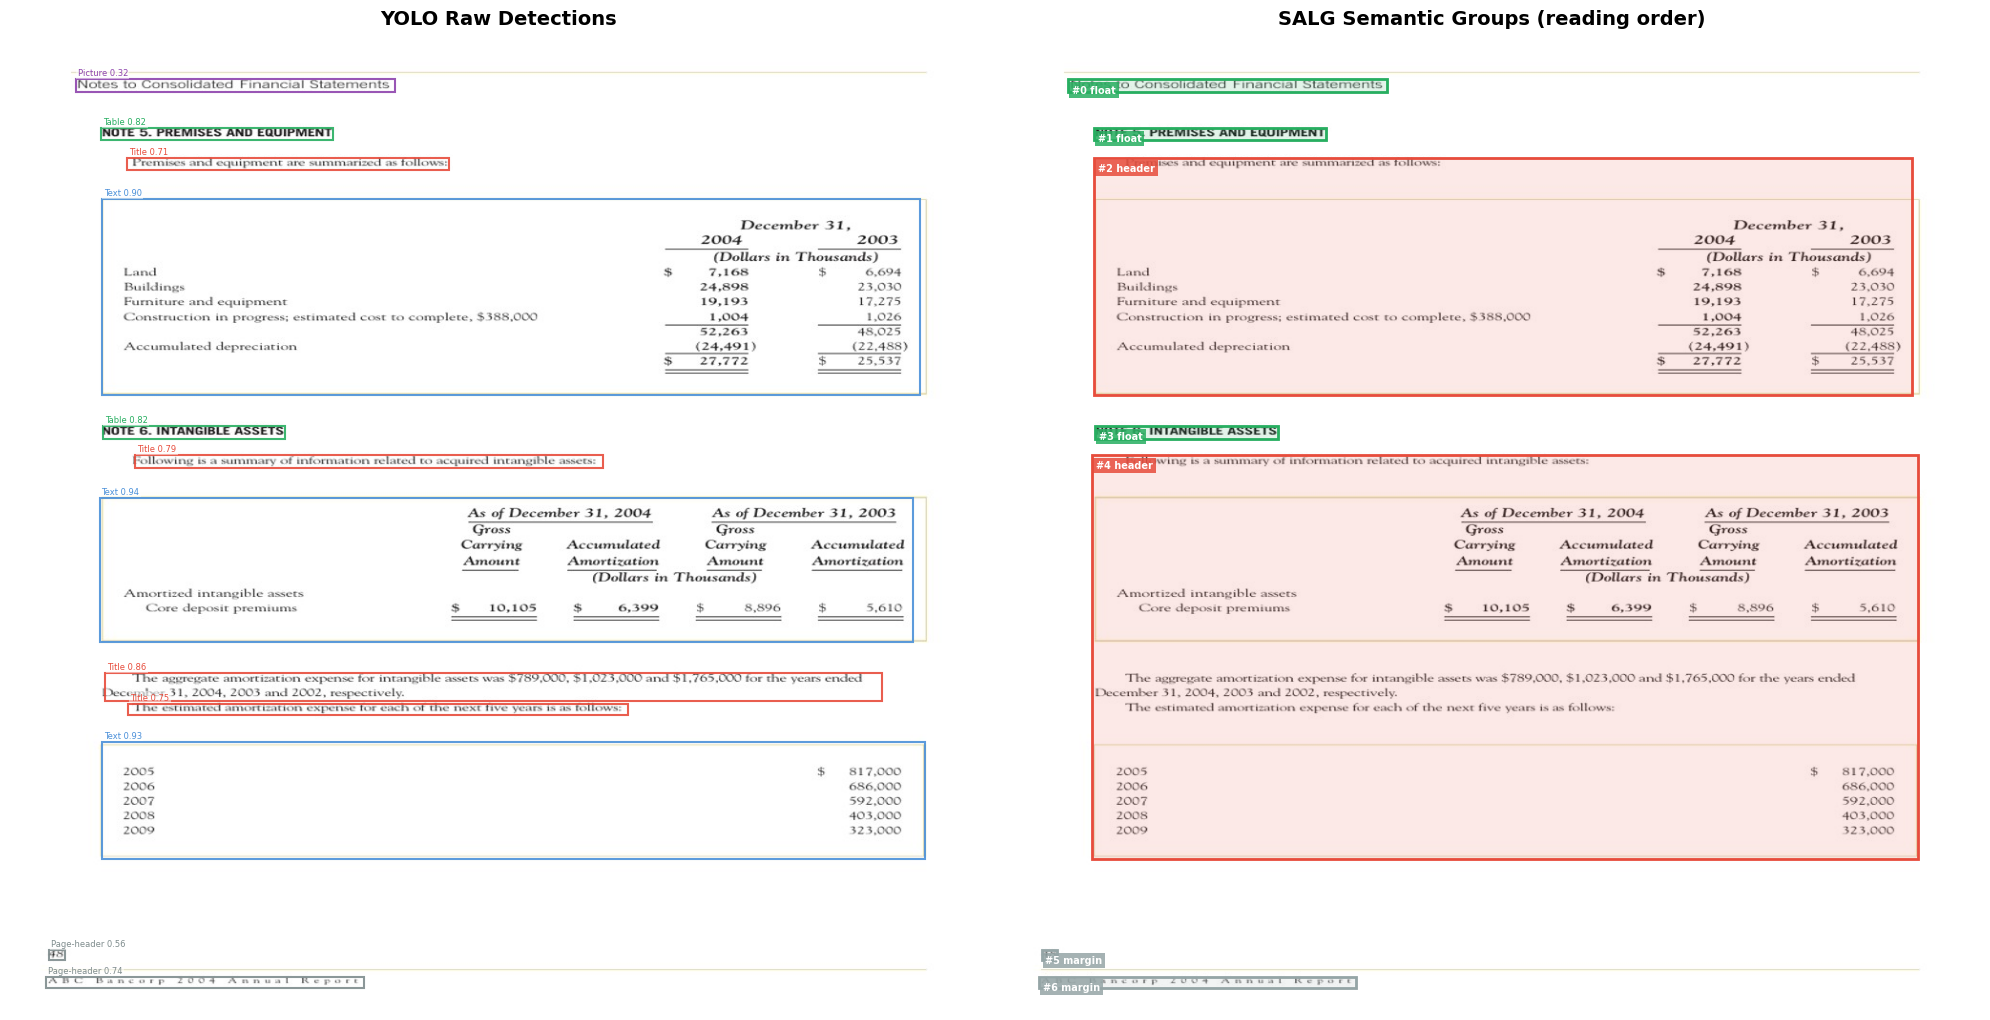


✅ Saved to /content/drive/MyDrive/doclayout_yolo/runs/salg_visualization.png


In [10]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.cm as cm
import numpy as np

# Color per class
COLORS = {
    'Text'           : '#4A90D9',
    'Title'          : '#E74C3C',
    'Section-header' : '#F39C12',
    'Table'          : '#27AE60',
    'Picture'        : '#8E44AD',
    'Caption'        : '#16A085',
    'List-item'      : '#2980B9',
    'Formula'        : '#D35400',
    'Page-header'    : '#7F8C8D',
    'Page-footer'    : '#7F8C8D',
    'Footnote'       : '#95A5A6',
}
GROUP_COLORS = {
    'header'  : '#E74C3C',
    'section' : '#F39C12',
    'flow'    : '#3498DB',
    'float'   : '#27AE60',
    'margin'  : '#95A5A6',
    'isolated': '#BDC3C7',
}

fig, axes = plt.subplots(1, 2, figsize=(20, 14))

# ── Left: raw YOLO detections ──
ax = axes[0]
ax.imshow(img)
ax.set_title('YOLO Raw Detections', fontsize=14, fontweight='bold')
for det in detections:
    x1,y1,x2,y2 = det.box
    c = COLORS.get(det.cls_name, '#AAAAAA')
    rect = patches.Rectangle((x1,y1), x2-x1, y2-y1,
                               linewidth=1.5, edgecolor=c, facecolor='none', alpha=0.9)
    ax.add_patch(rect)
    ax.text(x1+2, y1-4, f'{det.cls_name} {det.conf:.2f}',
            fontsize=6, color=c,
            bbox=dict(facecolor='white', alpha=0.5, pad=1, edgecolor='none'))
ax.axis('off')

# ── Right: SALG groups ──
ax = axes[1]
ax.imshow(img)
ax.set_title('SALG Semantic Groups (reading order)', fontsize=14, fontweight='bold')
cmap = cm.get_cmap('tab20', len(groups))

for g in groups:
    x1,y1,x2,y2 = g.bbox
    c = GROUP_COLORS.get(g.group_type, '#AAAAAA')
    rect = patches.Rectangle((x1,y1), x2-x1, y2-y1,
                               linewidth=2, edgecolor=c,
                               facecolor=c, alpha=0.12)
    ax.add_patch(rect)
    border = patches.Rectangle((x1,y1), x2-x1, y2-y1,
                                 linewidth=2, edgecolor=c, facecolor='none')
    ax.add_patch(border)
    ax.text(x1+4, y1+14, f'#{g.reading_order} {g.group_type}',
            fontsize=7, color='white', fontweight='bold',
            bbox=dict(facecolor=c, alpha=0.85, pad=2, edgecolor='none'))
ax.axis('off')

plt.tight_layout()
save_path = f'{OUT_DIR}/salg_visualization.png'
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'\n✅ Saved to {save_path}')

## Cell 11 — Export Structured JSON (SALG Output)

Exports the semantic layout as a structured JSON — useful for downstream tasks (RAG, document QA, table extraction).

In [11]:
import json
from pathlib import Path

def groups_to_json(groups: List[SemanticGroup], img_path: str) -> dict:
    output = {
        'source_image': img_path,
        'total_groups': len(groups),
        'layout': []
    }
    for g in groups:
        block = {
            'reading_order': g.reading_order,
            'type': g.group_type,
            'bbox': list(g.bbox),
            'elements': [
                {
                    'class': e.cls_name,
                    'confidence': round(e.conf, 4),
                    'bbox': list(e.box)
                }
                for e in g.elements
            ]
        }
        if g.anchor:
            block['anchor_class'] = g.anchor.cls_name
        output['layout'].append(block)
    return output

json_output = groups_to_json(groups, test_img_path)
json_save_path = f'{OUT_DIR}/salg_output.json'
with open(json_save_path, 'w') as f:
    json.dump(json_output, f, indent=2)

print(f'✅ Saved structured layout JSON: {json_save_path}')
print(json.dumps(json_output['layout'][:3], indent=2))  # Preview first 3 groups

✅ Saved structured layout JSON: /content/drive/MyDrive/doclayout_yolo/runs/salg_output.json
[
  {
    "reading_order": 0,
    "type": "float",
    "bbox": [
      68.46878814697266,
      48.690677642822266,
      402.73760986328125,
      62.165897369384766
    ],
    "elements": [
      {
        "class": "Picture",
        "confidence": 0.3176,
        "bbox": [
          68.46878814697266,
          48.690677642822266,
          402.73760986328125,
          62.165897369384766
        ]
      }
    ],
    "anchor_class": "Picture"
  },
  {
    "reading_order": 1,
    "type": "float",
    "bbox": [
      95.41697692871094,
      99.67044830322266,
      338.667236328125,
      112.55950927734375
    ],
    "elements": [
      {
        "class": "Table",
        "confidence": 0.8159,
        "bbox": [
          95.41697692871094,
          99.67044830322266,
          338.667236328125,
          112.55950927734375
        ]
      }
    ],
    "anchor_class": "Table"
  },
  {
    "rea

## Cell 12 — (Optional) Run on Your Own Image

Upload a document image (PDF page screenshot, scanned doc, etc.)...


Saving Screenshot 2026-04-04 222933.png to Screenshot 2026-04-04 222933.png


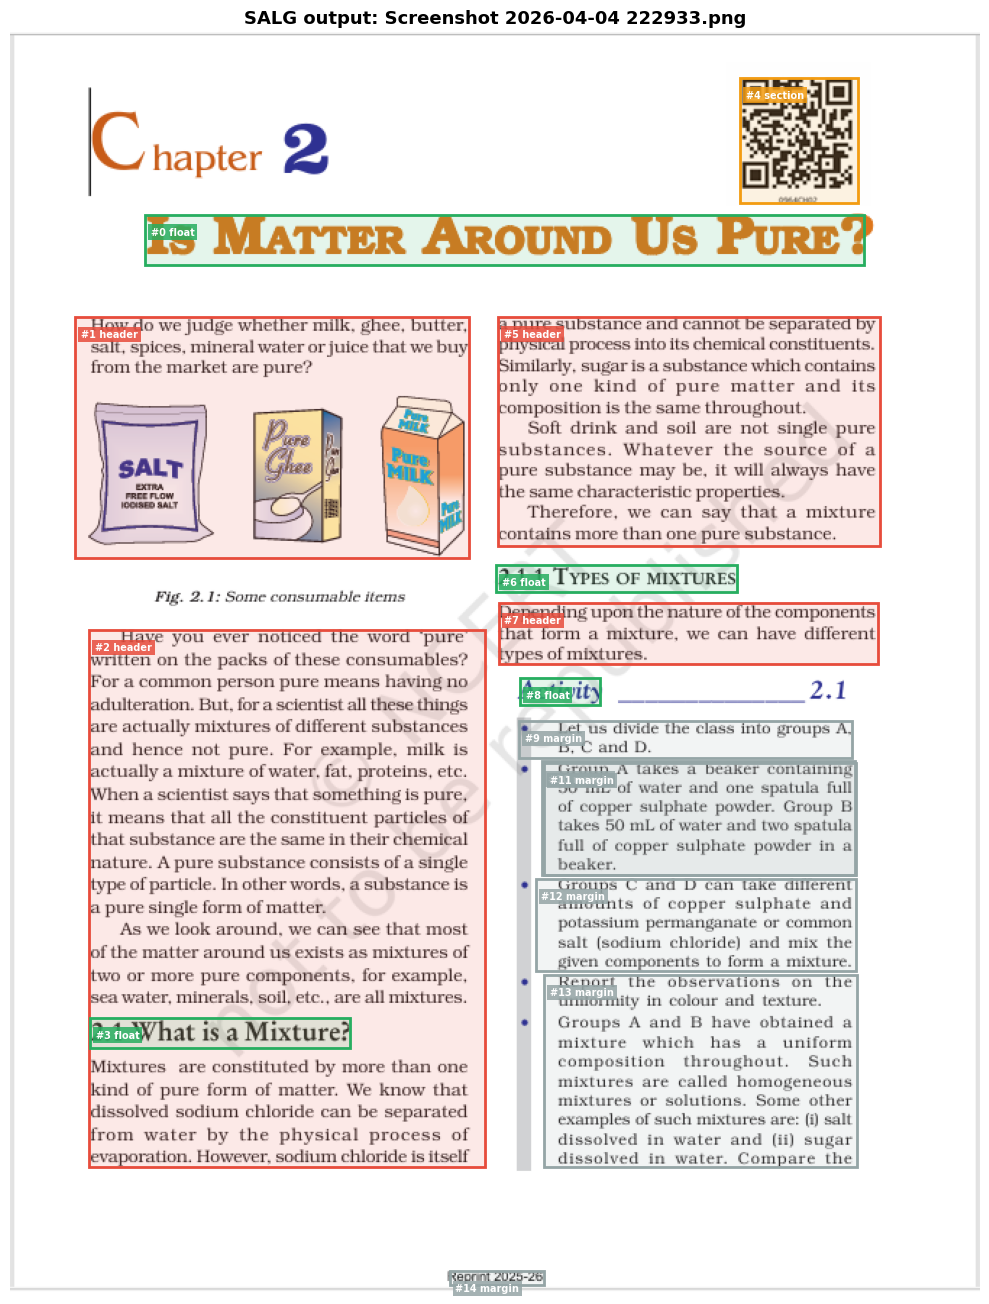

Done: 15 semantic groups detected.
Saved to: /content/drive/MyDrive/doclayout_yolo/runs/Screenshot 2026-04-04 222933_salg.png


In [16]:
from google.colab import files
from pathlib import Path
from PIL import Image as PILImage
import matplotlib.pyplot as plt
import matplotlib.patches as patches

print('Upload a document image (PDF page screenshot, scanned doc, etc.)...')
uploaded = files.upload()

for fname, fbytes in uploaded.items():

    # Save uploaded file
    custom_path = f'{OUT_DIR}/{fname}'
    with open(custom_path, 'wb') as f:
        f.write(fbytes)

    # -------------------------------
    # Model inference
    # -------------------------------
    res = model_infer(
        custom_path,
        imgsz=640,      # quick test (1280 gives better precision)
        conf=0.25,
        iou=0.45,
        device=0,
        verbose=False
    )[0]

    # -------------------------------
    # Load image
    # -------------------------------
    img_c = PILImage.open(custom_path).convert('RGB')
    w, h = img_c.size

    # -------------------------------
    # Convert detections
    dets_c = [
        Detection(
            CLASSES[int(b.cls)],
            int(b.cls),
            float(b.conf),
            tuple(b.xyxy[0].tolist())
        )
        for b in res.boxes
    ]

    # -------------------------------
    # SALG grouping
    # -------------------------------
    salg_c = SALG(img_h=h, img_w=w)
    groups_c = salg_c.group(dets_c)

    # -------------------------------
    # Visualization
    # -------------------------------
    fig, ax = plt.subplots(1, 1, figsize=(10, 14))
    ax.imshow(img_c)
    ax.set_title(f'SALG output: {fname}', fontsize=13, fontweight='bold')

    for g in groups_c:
        x1, y1, x2, y2 = g.bbox
        c = GROUP_COLORS.get(g.group_type, '#AAAAAA')

        ax.add_patch(
            patches.Rectangle(
                (x1, y1),
                x2 - x1,
                y2 - y1,
                linewidth=2,
                edgecolor=c,
                facecolor=c,
                alpha=0.12
            )
        )

        ax.add_patch(
            patches.Rectangle(
                (x1, y1),
                x2 - x1,
                y2 - y1,
                linewidth=2,
                edgecolor=c,
                facecolor='none'
            )
        )

        ax.text(
            x1 + 4,
            y1 + 14,
            f'#{g.reading_order} {g.group_type}',
            fontsize=7,
            color='white',
            fontweight='bold',
            bbox=dict(facecolor=c, alpha=0.85, pad=2, edgecolor='none')
        )

    ax.axis('off')
    plt.tight_layout()

    # Save result
    save_path = f'{OUT_DIR}/{Path(fname).stem}_salg.png'
    plt.savefig(save_path, dpi=150, bbox_inches='tight')

    plt.show()

    print(f'Done: {len(groups_c)} semantic groups detected.')
    print(f'Saved to: {save_path}')

In [17]:
best_model_path = f'{OUT_DIR}/yolo26{MODEL_SIZE}_doclaynet/weights/best.pt'

In [18]:
import shutil

saved_path = f'{OUT_DIR}/final_doclayout_model.pt'
shutil.copy(best_model_path, saved_path)

print(f"✅ Model saved at: {saved_path}")

✅ Model saved at: /content/drive/MyDrive/doclayout_yolo/runs/final_doclayout_model.pt
